In [41]:
# Import required libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [42]:
# Set Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [43]:
# Load EuroSAT Dataset
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

dataset = datasets.EuroSAT(
    root="./data",
    download=True,
    transform=transform
)

dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

In [44]:
# Define Encoder for 64X64 RGB

class Encoder(nn.Module):
    def __init__(self, latent_dimension):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 4, 2, 1)
        self.conv2 = nn.Conv2d(32, 64, 4, 2, 1)
        self.conv3 = nn.Conv2d(64, 128, 4, 2, 1)
        self.conv4 = nn.Conv2d(128, 256, 4, 2, 1)

        self.fc_mu = nn.Linear(256*4*4, latent_dimension)
        self.fu_logVar = nn.Linear(256*4*4, latent_dimension)

    def forward(self, input):
        input = F.relu(self.conv1(input))
        input = F.relu(self.conv2(input))
        input = F.relu(self.conv3(input))
        input = F.relu(self.conv4(input))

        input = input.view(input.size(0), -1)

        mu = self.fc_mu(input)
        log_var = self.fu_logVar(input)

        return mu, log_var


In [45]:
# Reparameterization (Sampling)

def reparameterized(mu, log_var):
        std = torch.exp(0.5 * log_var) # compute standared deviation
        eps = torch.randn_like(std) # eps is randomness 
        return mu + std * eps # sampling

In [46]:
# Decoder

class Decoder(nn.Module):
    def __init__(self, latent_dimension):
        super().__init__()

        self.fc = nn.Linear(latent_dimension, 256*4*4)
        self.deconv1 = nn.ConvTranspose2d(256, 128, 4, 2, 1)
        self.deconv2 = nn.ConvTranspose2d(128, 64, 4, 2, 1)
        self.deconv3 = nn.ConvTranspose2d(64, 32, 4, 2, 1)
        self.deconv4 = nn.ConvTranspose2d(32, 3, 4, 2, 1)

    def forward(self, z):
        de_input = self.fc(z)
        de_input = de_input.view(z.size(0), 256, 4, 4)

        de_input = F.relu(self.deconv1(de_input))
        de_input = F.relu(self.deconv2(de_input))
        de_input = F.relu(self.deconv3(de_input))
        de_input = torch.sigmoid(self.deconv4(de_input))

        return de_input;

In [47]:
# VAE Model

class VAE(nn.Module):
    def __init__(self, latent_dimension):
        super().__init__()

        self.encoder = Encoder(latent_dimension)
        self.decoder = Decoder(latent_dimension)

    def forward(self, input):
        mu, log_var = self.encoder(input)
        z = reparameterized(mu, log_var)
        input_recon = self.decoder(z)

        return input_recon, mu, log_var

In [48]:
# Loss function
def vae_loss(recon_x, x, mu, log_var):

    recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')

    kl = -0.5 * torch.sum(
        1 + log_var - mu.pow(2) - log_var.exp()
    )
    beta = 0.0005
    loss = recon_loss + beta * kl
    return loss

In [49]:
# Initialize the model

latent_dimension = 64
model = VAE(latent_dimension).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

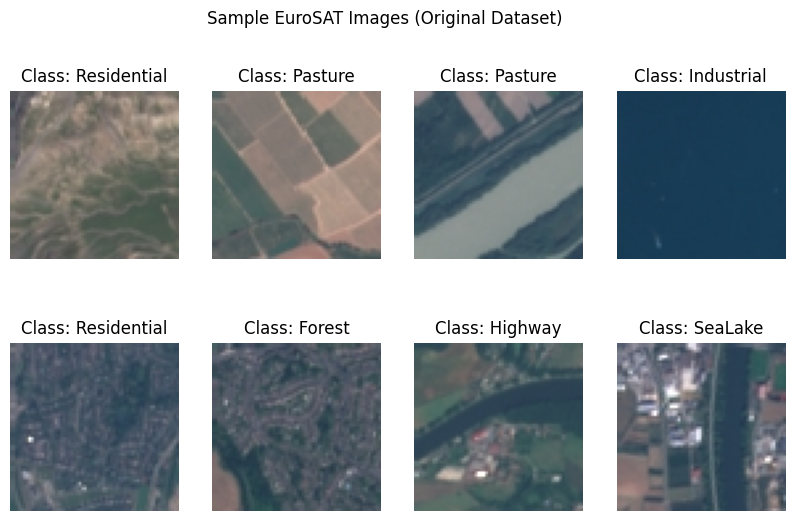

In [ ]:
# Generate the Raw Images pre-decoding using VAE model
images, labels = next(iter(dataloader))

plt.figure(figsize=(10,6))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.title(f"Class: {dataset.classes[labels[i]]}")
    plt.axis("off")

plt.suptitle("Sample EuroSAT Images (Original Dataset)")
plt.show()

In [51]:
# Training Loop

epochs = 20
history_of_loss = []

for epoch in range(epochs):
    total_loss = 0
    
    for images, _ in dataloader:

        images = images.to(device)
        recon, mu, log_var = model(images)
        loss = vae_loss(recon, images, mu, log_var)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader.dataset)
    history_of_loss.append(avg_loss)

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

Epoch 1, Loss: 7713.3316
Epoch 2, Loss: 7607.4568
Epoch 3, Loss: 7588.2204
Epoch 4, Loss: 7567.9815
Epoch 5, Loss: 7563.6571
Epoch 6, Loss: 7557.7364
Epoch 7, Loss: 7554.4848
Epoch 8, Loss: 7553.7433
Epoch 9, Loss: 7548.7537
Epoch 10, Loss: 7547.4865
Epoch 11, Loss: 7546.4442
Epoch 12, Loss: 7544.6008
Epoch 13, Loss: 7543.3918
Epoch 14, Loss: 7543.1368
Epoch 15, Loss: 7541.6277
Epoch 16, Loss: 7540.9924
Epoch 17, Loss: 7540.1251
Epoch 18, Loss: 7539.4193
Epoch 19, Loss: 7538.4048
Epoch 20, Loss: 7537.8930


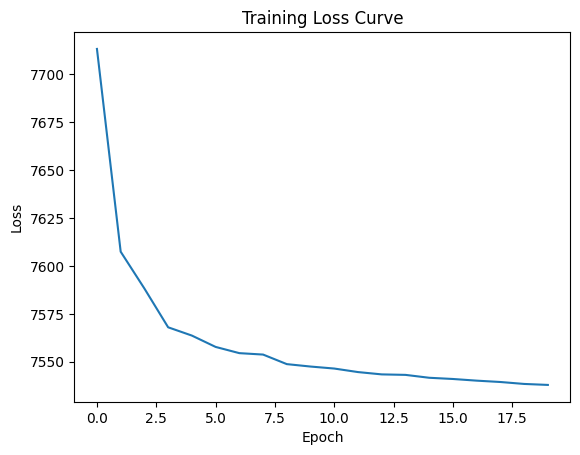

In [52]:
# Plot Training Loss
plt.plot(history_of_loss)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

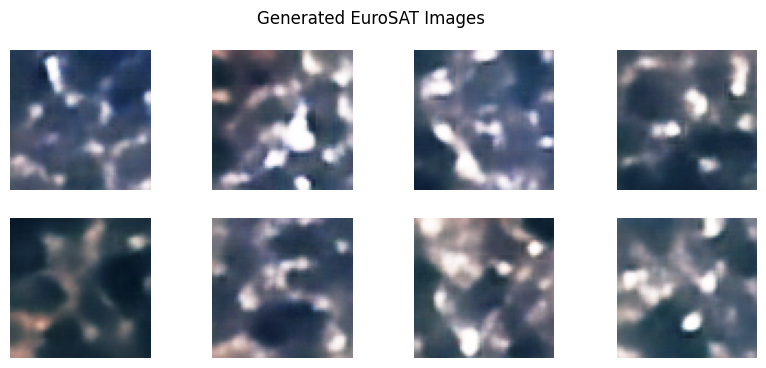

In [53]:
# Generate new Satelite Images

model.eval()

with torch.no_grad():
    z = torch.randn(8, latent_dimension).to(device)
    reGenerated = model.decoder(z).cpu()

plt.figure(figsize=(10,4))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(reGenerated[i].permute(1,2,0))
    plt.axis("off")

plt.suptitle("Generated EuroSAT Images")
plt.show()